In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


In [4]:
df = pd.read_csv('../data/estudiantes_unidos.csv')

In [5]:
df

,PERIODO,FACULTAD,UNIDAD,PENSUM,DOCUMENTO,NOMBRES,CIENCIAS BÁSICAS,CIENCIAS BÁSICAS DE INGENIERÍA,INGENIERÍA APLICADA,INSTITUCIONAL,...,ES_GRUPO_ETNICO,GRUPO_ETNICO_CAT,HORAS_FUERA_CASA,RECURSOS_TECNOLOGICOS,HERMANOS_CAT,CARGA_LABORAL,CARGA_HOGAR,CONDICION_DISCAPACIDAD,HABITOS_RIESGO,IMC_CAT
0,2019-1,FACULTAD DE INGENIERÍA,"UNIDAD REGIONAL, SEDE FUSAGASUGÁ",INGENIERIA DE SISTEMAS Y COMPUTACION 2020 FUSA...,1000136072,FORERO HERRERA TANIA NICKOLL,3.553846,3.956154,3.951915,3.897200,...,No,No étnico,ALTO,COMPLETOS,NINGUNO,NO_TRABAJA,HOGAR_SIN_NINOS,COGNITIVA,BAJO,NORMAL
1,2019-1,FACULTAD DE INGENIERÍA,"UNIDAD REGIONAL, SEDE FUSAGASUGÁ",INGENIERIA DE SISTEMAS Y COMPUTACION 2020 FUSA...,1000320087,MESA BLANCO LEONARDO JUAN,3.310833,3.297368,3.661538,3.761000,...,No,No étnico,MEDIO,COMPLETOS,POCOS_1_2,NO_TRABAJA,CON_NINOS_1_2,COGNITIVA,NINGUNO,NORMAL
2,2019-1,FACULTAD DE INGENIERÍA,"UNIDAD REGIONAL, SEDE FUSAGASUGÁ",INGENIERIA DE SISTEMAS Y COMPUTACION 2020 FUSA...,1000592838,BAUTISTA DIAZ DANIEL EDUARDO,3.475000,3.625714,3.960278,3.890833,...,No,No étnico,BAJO,BASICOS,NINGUNO,NO_TRABAJA,HOGAR_SIN_NINOS,COGNITIVA,NINGUNO,NORMAL
3,2019-1,FACULTAD DE INGENIERÍA,"UNIDAD REGIONAL, SEDE FUSAGASUGÁ",INGENIERIA DE SISTEMAS Y COMPUTACION 2020 FUSA...,1001346777,SUAREZ HEREDIA JUAN SEBASTIAN,3.171429,2.900000,3.100000,3.000000,...,No,No étnico,ALTO,BASICOS,POCOS_1_2,NO_TRABAJA,CON_NINOS_1_2,COGNITIVA,NINGUNO,SOBREPESO
4,2019-1,FACULTAD DE INGENIERÍA,"UNIDAD REGIONAL, SEDE FUSAGASUGÁ",INGENIERIA DE SISTEMAS Y COMPUTACION 2020 FUSA...,1003515700,ESCOBAR VASQUEZ JENIFFER DAYANA,3.328571,2.623529,3.900000,3.485714,...,No,No étnico,BAJO,COMPLETOS,VARIOS_3_MAS,NO_TRABAJA,CON_NINOS_1_2,COGNITIVA,NINGUNO,NORMAL
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
757,2024-2,FACULTAD DE INGENIERÍA,"UNIDAD REGIONAL, SEDE FUSAGASUGÁ",INGENIERIA DE SISTEMAS Y COMPUTACION 2020 FUSA...,1104774703,PINILLA VILLARRAGA DAVID SANTIAGO,NaN,4.726000,4.330000,3.830000,...,No,No étnico,BAJO,BASICOS,POCOS_1_2,NO_TRABAJA,CON_NINOS_1_2,SIN,NINGUNO,NORMAL
758,2024-2,FACULTAD DE INGENIERÍA,"UNIDAD REGIONAL, SEDE FUSAGASUGÁ",INGENIERIA DE SISTEMAS Y COMPUTACION 2020 FUSA...,1105465272,VILLARREAL CASTILLO DIEGO ANDRES,NaN,4.788000,3.710000,4.375000,...,No,No étnico,BAJO,BASICOS,POCOS_1_2,NO_TRABAJA,SOLO_SIN_NINOS,SIN,NINGUNO,NORMAL
759,2024-2,FACULTAD DE INGENIERÍA,"UNIDAD REGIONAL, SEDE FUSAGASUGÁ",INGENIERIA DE SISTEMAS Y COMPUTACION 2020 FUSA...,1105840288,GONZALEZ GONZALEZ GIOVANNI STIVEN,NaN,4.346000,3.720000,4.060000,...,No,No étnico,MEDIO,BASICOS,POCOS_1_2,NO_TRABAJA,HOGAR_SIN_NINOS,SIN,NINGUNO,NORMAL
760,2024-2,FACULTAD DE INGENIERÍA,"UNIDAD REGIONAL, SEDE FUSAGASUGÁ",INGENIERIA DE SISTEMAS Y COMPUTACION 2020 FUSA...,1110233645,RODRIGUEZ MENDOZA DANIEL ESTEBAN,NaN,4.274000,3.860000,4.080000,...,No,No étnico,MEDIO,COMPLETOS,POCOS_1_2,NO_TRABAJA,CON_NINOS_1_2,SIN,NINGUNO,SOBREPESO


In [6]:
# Booleano por fila (True si la fila ya apareció antes)
dup_mask = df.duplicated()

# ¿Cuántas filas duplicadas hay?
dup_mask.sum()

# Ver solo las filas duplicadas (sin la primera ocurrencia)
df[dup_mask]

# Ver TODAS las ocurrencias de las filas repetidas (incluye la primera)
df[df.duplicated(keep=False)].sort_values(list(df.columns))

,PERIODO,FACULTAD,UNIDAD,PENSUM,DOCUMENTO,NOMBRES,CIENCIAS BÁSICAS,CIENCIAS BÁSICAS DE INGENIERÍA,INGENIERÍA APLICADA,INSTITUCIONAL,...,ES_GRUPO_ETNICO,GRUPO_ETNICO_CAT,HORAS_FUERA_CASA,RECURSOS_TECNOLOGICOS,HERMANOS_CAT,CARGA_LABORAL,CARGA_HOGAR,CONDICION_DISCAPACIDAD,HABITOS_RIESGO,IMC_CAT


In [7]:
# Cuántos DOCUMENTO están repetidos (más de 1 vez)
dup_docs = df['DOCUMENTO'].duplicated(keep=False).sum()  # cuenta ocurrencias repetidas
# O contar claves únicas repetidas:
n_claves_repetidas = (df['DOCUMENTO'].value_counts() > 1).sum()

# Ver todas las filas con DOCUMENTO duplicado
df[df['DOCUMENTO'].duplicated(keep=False)].sort_values('DOCUMENTO')

# Ver el conteo por DOCUMENTO
df['DOCUMENTO'].value_counts().loc[lambda s: s > 1]


Series([], Name: count, dtype: int64)

In [8]:
df.isnull().sum()/len(df)*100

PERIODO                             0.000000
FACULTAD                            0.000000
UNIDAD                              0.000000
PENSUM                              0.000000
DOCUMENTO                           0.000000
NOMBRES                             0.000000
CIENCIAS BÁSICAS                   14.304462
CIENCIAS BÁSICAS DE INGENIERÍA      0.262467
INGENIERÍA APLICADA                 1.574803
INSTITUCIONAL                       0.262467
TOTAL_BAJO_RENDIMIENTO_REA          0.000000
DESERTA                             0.000000
GENERO                              0.000000
UBICACION_SEMESTRAL                 0.000000
MEDIO_TRANSPORTE                    0.000000
FRECUENCIA_TRANSPORTE               0.000000
FUENTES_FINANCIACION                0.000000
PERSONAS_A_CARGO                    0.000000
DIFICULTAD_PAGO_MATRICULA           0.000000
TURNO_TRABAJO_ESTUDIO               0.000000
TIPO_VIVIENDA_RESIDENCIA            0.000000
ZONA_VIVIENDA_RESIDENCIA            0.000000
VIVE_PADRE

In [9]:
df["FRECUENCIA_USO_CANALES_ATENCION"].value_counts()

FRECUENCIA_USO_CANALES_ATENCION
Con poca frecuencia    362
Frecuentemente         187
Casi nunca             166
Nunca                   45
Name: count, dtype: int64

In [10]:
df["FRECUENCIA_USO_CANALES_ATENCION"] = df["FRECUENCIA_USO_CANALES_ATENCION"].fillna("Nunca")

In [11]:
df["HERMANOS_CAT"].value_counts()


HERMANOS_CAT
POCOS_1_2       464
VARIOS_3_MAS    204
NINGUNO          92
Name: count, dtype: int64

In [12]:
df["HERMANOS_CAT"] = df["HERMANOS_CAT"].fillna("NINGUNO")


In [13]:
df["IMC_CAT"].value_counts()

IMC_CAT
NORMAL       552
SOBREPESO     99
BAJO_PESO     83
OBESIDAD      19
Name: count, dtype: int64

In [14]:
df["IMC_CAT"] = df["IMC_CAT"].fillna("NORMAL")

In [15]:
df["VICTIMA_VIOLENCIA"].value_counts()


VICTIMA_VIOLENCIA
No    660
Si     21
Name: count, dtype: int64

In [16]:
df["VICTIMA_VIOLENCIA"] = df["VICTIMA_VIOLENCIA"].fillna("No responde")

In [17]:
df["CIENCIAS BÁSICAS"]

0      3.553846
1      3.310833
2      3.475000
3      3.171429
4      3.328571
         ...   
757         NaN
758         NaN
759         NaN
760         NaN
761         NaN
Name: CIENCIAS BÁSICAS, Length: 762, dtype: float64

(array([  1.,   1.,   2.,   1.,   5.,  18.,  85., 220., 233.,  87.]),
 array([0.        , 0.48785714, 0.97571429, 1.46357143, 1.95142857,
        2.43928571, 2.92714286, 3.415     , 3.90285714, 4.39071429,
        4.87857143]),
 <BarContainer object of 10 artists>)

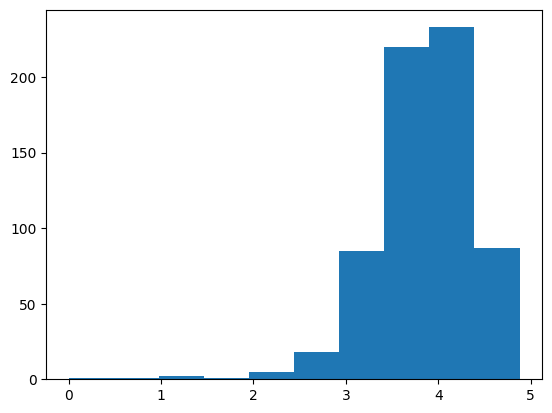

In [18]:
plt.hist(df["CIENCIAS BÁSICAS"])

(array([  1.,   1.,   1.,   0.,   4.,  12.,  40., 134., 342., 225.]),
 array([0.   , 0.481, 0.962, 1.443, 1.924, 2.405, 2.886, 3.367, 3.848,
        4.329, 4.81 ]),
 <BarContainer object of 10 artists>)

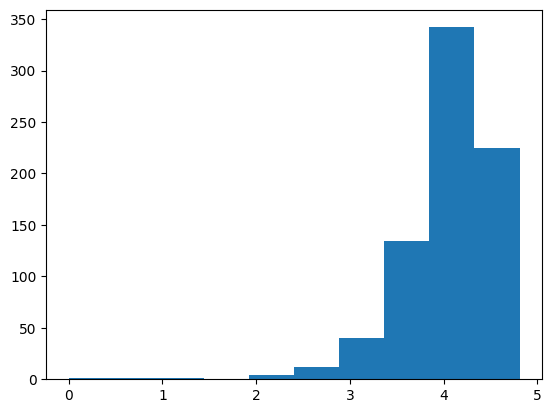

In [19]:
plt.hist(df["CIENCIAS BÁSICAS DE INGENIERÍA"])

(array([  3.,   0.,   2.,   5.,  12.,  16.,  82., 242., 263., 125.]),
 array([0.   , 0.499, 0.998, 1.497, 1.996, 2.495, 2.994, 3.493, 3.992,
        4.491, 4.99 ]),
 <BarContainer object of 10 artists>)

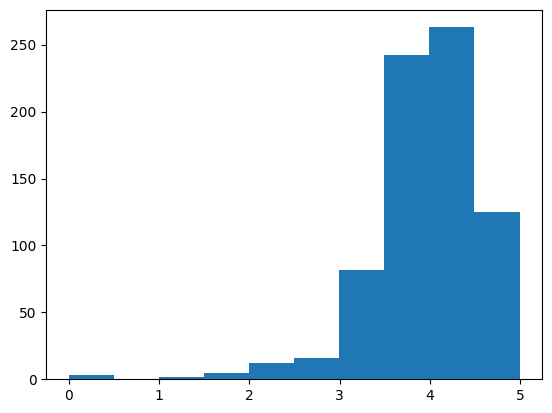

In [20]:
plt.hist(df["INGENIERÍA APLICADA"])


(array([  3.,   1.,   4.,   3.,   3.,   7.,  32., 136., 406., 165.]),
 array([0.        , 0.47671429, 0.95342857, 1.43014286, 1.90685714,
        2.38357143, 2.86028571, 3.337     , 3.81371429, 4.29042857,
        4.76714286]),
 <BarContainer object of 10 artists>)

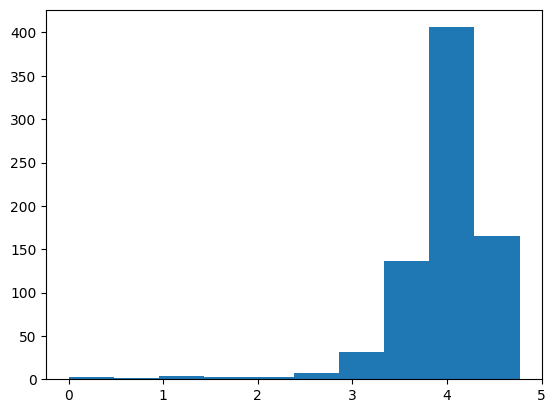

In [21]:
plt.hist(df["INSTITUCIONAL"])


In [22]:
dup_doc = df.duplicated(subset=["DOCUMENTO"]).sum()
dup_doc, dup_doc / len(df)

(np.int64(0), np.float64(0.0))

In [23]:
cols = ["CIENCIAS BÁSICAS", "CIENCIAS BÁSICAS DE INGENIERÍA", "INGENIERÍA APLICADA", "INSTITUCIONAL"]
df[cols] = df[cols].apply(pd.to_numeric, errors="coerce")  # convierte a numérico
df[cols] = df[cols].round(3)                               # deja 3 decimales

In [24]:
filtro_nan_cb = df["CIENCIAS BÁSICAS"].isna()
df_nan_cb = df[filtro_nan_cb]

In [25]:
pd.set_option('display.max_columns', None)

In [26]:
df_nan_cb

,PERIODO,FACULTAD,UNIDAD,PENSUM,DOCUMENTO,NOMBRES,CIENCIAS BÁSICAS,CIENCIAS BÁSICAS DE INGENIERÍA,INGENIERÍA APLICADA,INSTITUCIONAL,TOTAL_BAJO_RENDIMIENTO_REA,DESERTA,GENERO,UBICACION_SEMESTRAL,MEDIO_TRANSPORTE,FRECUENCIA_TRANSPORTE,FUENTES_FINANCIACION,PERSONAS_A_CARGO,DIFICULTAD_PAGO_MATRICULA,TURNO_TRABAJO_ESTUDIO,TIPO_VIVIENDA_RESIDENCIA,ZONA_VIVIENDA_RESIDENCIA,VIVE_PADRES_FAMILIAR,SISBEN,NUM_HIJOS,VIVE_PERSONAS_MAYORES,VIVE_PERSONAS_PATOLOGIAS,VICTIMA_VIOLENCIA,FRECUENCIA_USO_CANALES_ATENCION,ORIENTACION_CAT,COMUNA,NIV_EDUCATIVO_PADRE_CAT,NIV_EDUCATIVO_MADRE_CAT,ES_VULNERABLE,ES_GRUPO_ETNICO,GRUPO_ETNICO_CAT,HORAS_FUERA_CASA,RECURSOS_TECNOLOGICOS,HERMANOS_CAT,CARGA_LABORAL,CARGA_HOGAR,CONDICION_DISCAPACIDAD,HABITOS_RIESGO,IMC_CAT
12,2019-1,FACULTAD DE INGENIERÍA,"UNIDAD REGIONAL, SEDE FUSAGASUGÁ",INGENIERIA DE SISTEMAS Y COMPUTACION 2020 FUSA...,1015451974,CARVAJAL CORTES JUAN SEBASTIAN,NaN,3.117,2.929,3.460,12,1,M,9,Servicio público,Baja frecuencia,Recursos propios,SIN_CARGAS,Si,Diurno,Propia pagada,Zona urbana,Si,Si,0,Si,No,No,Casi nunca,No responde,Comuna Centro,Básica,Media,No,No,No étnico,MEDIO,BASICOS,POCOS_1_2,NO_TRABAJA,HOGAR_SIN_NINOS,MULTIPLE,BAJO,OBESIDAD
145,2019-1,FACULTAD DE INGENIERÍA,"UNIDAD REGIONAL, SEDE FUSAGASUGÁ",INGENIERIA DE SISTEMAS 2013,1019015125,ALARCON CALDERON ANDRES FELIPE,NaN,3.150,2.695,3.200,7,1,M,9,Vehículo motorizado,Alta frecuencia,Recursos propios,CON_CARGAS,Si,Diurno,Arrendada,Zona urbana,No,No,5,Si,No,No responde,Con poca frecuencia,No responde,Comuna Norte,Básica,Básica,No,No,No reportado,ALTO,BASICOS,VARIOS_3_MAS,NO_TRABAJA,CON_NINOS_1_2,MULTIPLE,BAJO,NORMAL
150,2019-1,FACULTAD DE INGENIERÍA,"UNIDAD REGIONAL, SEDE FUSAGASUGÁ",INGENIERIA DE SISTEMAS 2013,1026290752,BRICEÑO CASTRILLON WILLIAM ESTEBAN,NaN,3.100,2.373,0.000,7,0,M,9,Vehículo motorizado,Baja frecuencia,Recursos propios,CON_CARGAS,Si,Mixto,Propia pagada,Zona urbana,Si,No,1,No,No,No,Casi nunca,Heterosexual,Bogota,Media,Media,No,No,No étnico,BAJO,COMPLETOS,VARIOS_3_MAS,NO_TRABAJA,CON_NINOS_1_2,COGNITIVA,BAJO,SOBREPESO
151,2019-1,FACULTAD DE INGENIERÍA,"UNIDAD REGIONAL, SEDE FUSAGASUGÁ",INGENIERIA DE SISTEMAS 2013,1030622115,MORENO ORTIZ JUAN PABLO,NaN,3.100,3.129,3.700,3,0,M,9,A pie,Baja frecuencia,Recursos propios,CON_CARGAS,Si,Diurno,Arrendada,Zona urbana,Si,Si,1,Si,No,No,Con poca frecuencia,No responde,Comuna Norte,Media,Media,No,No,No étnico,BAJO,BASICOS,POCOS_1_2,NO_TRABAJA,CON_NINOS_1_2,COGNITIVA,NINGUNO,SOBREPESO
154,2019-1,FACULTAD DE INGENIERÍA,"UNIDAD REGIONAL, SEDE FUSAGASUGÁ",INGENIERIA DE SISTEMAS 2013,1032460863,VANEGAS MARTÍNEZ ANDRÉS SEBASTIÁN,NaN,4.250,2.925,1.800,3,1,M,8,Bicicleta,Baja frecuencia,Recursos propios,SIN_CARGAS,No,Diurno,Arrendada,Zona urbana,Si,No,0,No,No,No responde,Casi nunca,No responde,Bogota,Media,Superior,No,No,No étnico,MEDIO,COMPLETOS,POCOS_1_2,PARCIAL_1_20,SOLO_SIN_NINOS,COGNITIVA,NINGUNO,NORMAL
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
757,2024-2,FACULTAD DE INGENIERÍA,"UNIDAD REGIONAL, SEDE FUSAGASUGÁ",INGENIERIA DE SISTEMAS Y COMPUTACION 2020 FUSA...,1104774703,PINILLA VILLARRAGA DAVID SANTIAGO,NaN,4.726,4.330,3.830,0,0,M,2,Servicio público,Baja frecuencia,Recursos propios,SIN_CARGAS,No,Diurno,Propia pagada,Zona rural,Si,Si,0,Si,No,No,Casi nunca,Heterosexual,Comuna Norte,Media,Superior,Sí,No,No étnico,BAJO,BASICOS,POCOS_1_2,NO_TRABAJA,CON_NINOS_1_2,SIN,NINGUNO,NORMAL
758,2024-2,FACULTAD DE INGENIERÍA,"UNIDAD REGIONAL, SEDE FUSAGASUGÁ",INGENIERIA DE SISTEMAS Y COMPUTACION 2020 FUSA...,1105465272,VILLARREAL CASTILLO DIEGO ANDRES,NaN,4.788,3.710,4.375,0,0,M,2,Vehículo motorizado,Baja frecuencia,Crédito,SIN_CARGAS,No,Diurno,Propia pagada,Zona urbana,Si,No,0,No,No,No,Con poca frecuencia,Heterosexual,Comuna Sur Occidental,Media,Superior,Sí,No,No étnico,BAJO,BASICOS,POCOS_1_2,NO_TRABAJA,SOLO_SIN_NINOS,SIN,NINGUNO,NORMAL
759,2024-2,FACULTAD DE INGENIER

In [27]:
df[df["INGENIERÍA APLICADA"]==0]

,PERIODO,FACULTAD,UNIDAD,PENSUM,DOCUMENTO,NOMBRES,CIENCIAS BÁSICAS,CIENCIAS BÁSICAS DE INGENIERÍA,INGENIERÍA APLICADA,INSTITUCIONAL,TOTAL_BAJO_RENDIMIENTO_REA,DESERTA,GENERO,UBICACION_SEMESTRAL,MEDIO_TRANSPORTE,FRECUENCIA_TRANSPORTE,FUENTES_FINANCIACION,PERSONAS_A_CARGO,DIFICULTAD_PAGO_MATRICULA,TURNO_TRABAJO_ESTUDIO,TIPO_VIVIENDA_RESIDENCIA,ZONA_VIVIENDA_RESIDENCIA,VIVE_PADRES_FAMILIAR,SISBEN,NUM_HIJOS,VIVE_PERSONAS_MAYORES,VIVE_PERSONAS_PATOLOGIAS,VICTIMA_VIOLENCIA,FRECUENCIA_USO_CANALES_ATENCION,ORIENTACION_CAT,COMUNA,NIV_EDUCATIVO_PADRE_CAT,NIV_EDUCATIVO_MADRE_CAT,ES_VULNERABLE,ES_GRUPO_ETNICO,GRUPO_ETNICO_CAT,HORAS_FUERA_CASA,RECURSOS_TECNOLOGICOS,HERMANOS_CAT,CARGA_LABORAL,CARGA_HOGAR,CONDICION_DISCAPACIDAD,HABITOS_RIESGO,IMC_CAT
297,2019-2,FACULTAD DE INGENIERÍA,"UNIDAD REGIONAL, SEDE FUSAGASUGÁ",INGENIERIA DE SISTEMAS 2013,1115918969,CASTAÑO GALE JHON MARCOS,1.333,3.55,0.0,1.675,5,1,M,2,A pie,Baja frecuencia,Beca,CON_CARGAS,No,Diurno,Propia pagandose,Zona urbana,Si,Si,0,No,No,No,Nunca,No responde,Comuna Oriental,Media,Media,No,No,No étnico,ALTO,COMPLETOS,NINGUNO,NO_TRABAJA,HOGAR_SIN_NINOS,COGNITIVA,NINGUNO,OBESIDAD
416,2021-1,FACULTAD DE INGENIERÍA,"UNIDAD REGIONAL, SEDE FUSAGASUGÁ",INGENIERIA DE SISTEMAS Y COMPUTACION 2020 FUSA...,1007429466,CABRERA MONTOYA JHONATAN STIVEN,NaN,0.52,0.0,NaN,6,1,M,0,Servicio público,Baja frecuencia,Recursos propios,SIN_CARGAS,Si,Mixto,Arrendada,Zona urbana,Si,No,0,No,No,No,Con poca frecuencia,No responde,Municipios Aledaños,Media,Media,No,No,No étnico,BAJO,BASICOS,VARIOS_3_MAS,NO_TRABAJA,CON_NINOS_1_2,COGNITIVA,NINGUNO,BAJO_PESO


In [28]:
areas = [
    "CIENCIAS BÁSICAS",
    "CIENCIAS BÁSICAS DE INGENIERÍA",
    "INGENIERÍA APLICADA",
    "INSTITUCIONAL"
]

# Intervalos: [0–0.99], [1–1.99], [2–2.99], [3–3.99], [4–5]
bins   = [0, 1, 2, 3, 4, 5.0001]  # 5.0001 para incluir 5
labels = ["0–0.99", "1–1.99", "2–2.99", "3–3.99", "4–5"]

for col in areas:
    s = pd.to_numeric(df[col], errors="coerce").clip(0, 5)  # numérico y en rango
    cat = pd.cut(s, bins=bins, labels=labels, include_lowest=True, right=True, ordered=True)
    cat = cat.astype("category").cat.add_categories(["Sin nota"])
    cat[s.isna()] = "Sin nota"
    df[f"{col}_bin"] = cat

In [29]:
df["CIENCIAS BÁSICAS_bin"].value_counts()

CIENCIAS BÁSICAS_bin
3–3.99      359
4–5         260
Sin nota    109
2–2.99       28
1–1.99        4
0–0.99        2
Name: count, dtype: int64

In [30]:
pd.crosstab(df["CIENCIAS BÁSICAS_bin"], df["DESERTA"], margins=True)

DESERTA,0,1,All
CIENCIAS BÁSICAS_bin,,,
0–0.99,0,2,2
1–1.99,0,4,4
2–2.99,11,17,28
3–3.99,299,60,359
4–5,250,10,260
Sin nota,100,9,109
All,660,102,762


<Axes: xlabel='CARGA_LABORAL'>

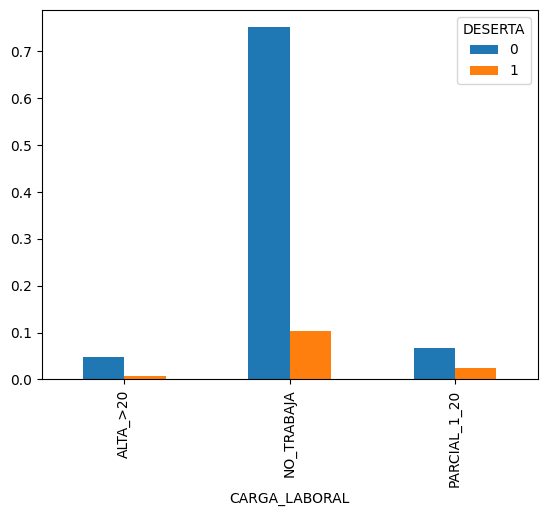

In [31]:
pd.crosstab(df["CARGA_LABORAL"], df["DESERTA"], normalize= True).plot(kind="bar")

In [32]:
pd.crosstab(df["CIENCIAS BÁSICAS DE INGENIERÍA_bin"], df["DESERTA"], margins=True)


DESERTA,0,1,All
CIENCIAS BÁSICAS DE INGENIERÍA_bin,,,
0–0.99,0,2,2
1–1.99,0,1,1
2–2.99,1,21,22
3–3.99,207,61,268
4–5,452,15,467
Sin nota,0,2,2
All,660,102,762


In [33]:
pd.crosstab(df["INGENIERÍA APLICADA_bin"], df["DESERTA"], margins=True)

DESERTA,0,1,All
INGENIERÍA APLICADA_bin,,,
0–0.99,0,3,3
1–1.99,1,6,7
2–2.99,12,23,35
3–3.99,274,51,325
4–5,372,8,380
Sin nota,1,11,12
All,660,102,762


In [34]:
pd.crosstab(df["INSTITUCIONAL_bin"], df["DESERTA"], margins=True)


DESERTA,0,1,All
INSTITUCIONAL_bin,,,
0–0.99,1,3,4
1–1.99,0,9,9
2–2.99,2,9,11
3–3.99,243,64,307
4–5,414,15,429
Sin nota,0,2,2
All,660,102,762


In [35]:
df.columns

Index(['PERIODO', 'FACULTAD', 'UNIDAD', 'PENSUM', 'DOCUMENTO', 'NOMBRES',
       'CIENCIAS BÁSICAS', 'CIENCIAS BÁSICAS DE INGENIERÍA',
       'INGENIERÍA APLICADA', 'INSTITUCIONAL', 'TOTAL_BAJO_RENDIMIENTO_REA',
       'DESERTA', 'GENERO', 'UBICACION_SEMESTRAL', 'MEDIO_TRANSPORTE',
       'FRECUENCIA_TRANSPORTE', 'FUENTES_FINANCIACION', 'PERSONAS_A_CARGO',
       'DIFICULTAD_PAGO_MATRICULA', 'TURNO_TRABAJO_ESTUDIO',
       'TIPO_VIVIENDA_RESIDENCIA', 'ZONA_VIVIENDA_RESIDENCIA',
       'VIVE_PADRES_FAMILIAR', 'SISBEN', 'NUM_HIJOS', 'VIVE_PERSONAS_MAYORES',
       'VIVE_PERSONAS_PATOLOGIAS', 'VICTIMA_VIOLENCIA',
       'FRECUENCIA_USO_CANALES_ATENCION', 'ORIENTACION_CAT', 'COMUNA',
       'NIV_EDUCATIVO_PADRE_CAT', 'NIV_EDUCATIVO_MADRE_CAT', 'ES_VULNERABLE',
       'ES_GRUPO_ETNICO', 'GRUPO_ETNICO_CAT', 'HORAS_FUERA_CASA',
       'RECURSOS_TECNOLOGICOS', 'HERMANOS_CAT', 'CARGA_LABORAL', 'CARGA_HOGAR',
       'CONDICION_DISCAPACIDAD', 'HABITOS_RIESGO', 'IMC_CAT',
       'CIENCIAS BÁSICAS_

In [36]:
data_model = ['TOTAL_BAJO_RENDIMIENTO_REA',
       'DESERTA', 'GENERO', 'UBICACION_SEMESTRAL', 'MEDIO_TRANSPORTE',
       'FRECUENCIA_TRANSPORTE', 'FUENTES_FINANCIACION', 'PERSONAS_A_CARGO',
       'DIFICULTAD_PAGO_MATRICULA', 'TURNO_TRABAJO_ESTUDIO',
       'TIPO_VIVIENDA_RESIDENCIA', 'ZONA_VIVIENDA_RESIDENCIA',
       'VIVE_PADRES_FAMILIAR', 'SISBEN', 'NUM_HIJOS', 'VIVE_PERSONAS_MAYORES',
       'VIVE_PERSONAS_PATOLOGIAS', 'VICTIMA_VIOLENCIA',
       'FRECUENCIA_USO_CANALES_ATENCION', 'ORIENTACION_CAT', 'COMUNA',
       'NIV_EDUCATIVO_PADRE_CAT', 'NIV_EDUCATIVO_MADRE_CAT', 'ES_VULNERABLE',
       'ES_GRUPO_ETNICO', 'GRUPO_ETNICO_CAT', 'HORAS_FUERA_CASA',
       'RECURSOS_TECNOLOGICOS', 'HERMANOS_CAT', 'CARGA_LABORAL', 'CARGA_HOGAR',
       'CONDICION_DISCAPACIDAD', 'HABITOS_RIESGO', 'IMC_CAT',
       'CIENCIAS BÁSICAS_bin', 'CIENCIAS BÁSICAS DE INGENIERÍA_bin',
       'INGENIERÍA APLICADA_bin', 'INSTITUCIONAL_bin']

In [ ]:
data_model = df[data_model].copy()

In [ ]:
data_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 762 entries, 0 to 761
Data columns (total 38 columns):
 #   Column                              Non-Null Count  Dtype   
---  ------                              --------------  -----   
 0   TOTAL_BAJO_RENDIMIENTO_REA          762 non-null    int64   
 1   DESERTA                             762 non-null    int64   
 2   GENERO                              762 non-null    object  
 3   UBICACION_SEMESTRAL                 762 non-null    int64   
 4   MEDIO_TRANSPORTE                    762 non-null    object  
 5   FRECUENCIA_TRANSPORTE               762 non-null    object  
 6   FUENTES_FINANCIACION                762 non-null    object  
 7   PERSONAS_A_CARGO                    762 non-null    object  
 8   DIFICULTAD_PAGO_MATRICULA           762 non-null    object  
 9   TURNO_TRABAJO_ESTUDIO               762 non-null    object  
 10  TIPO_VIVIENDA_RESIDENCIA            762 non-null    object  
 11  ZONA_VIVIENDA_RESIDENCIA        

In [ ]:
data_model.to_csv("data_model.csv", index=False, encoding="utf-8")

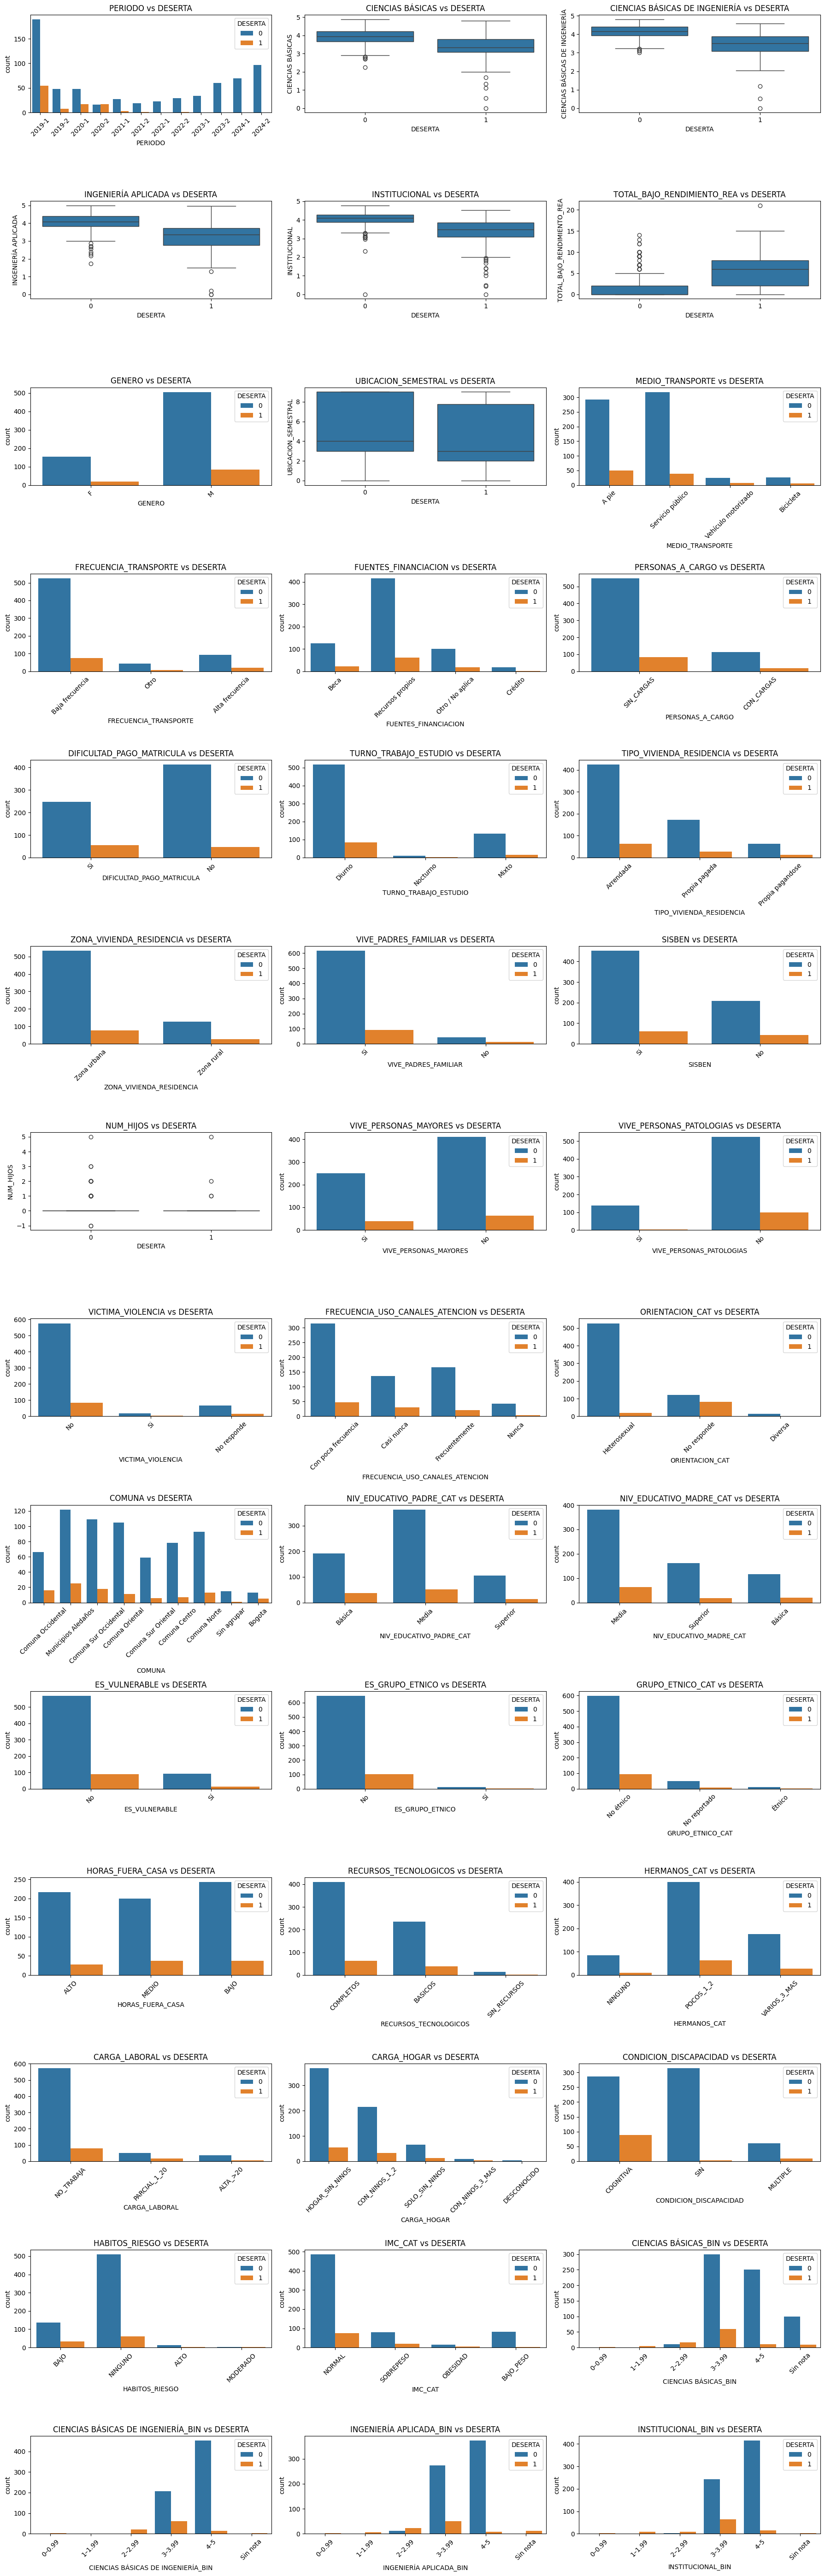

In [44]:
# === Normalizar nombres ===
df.columns = df.columns.str.strip().str.upper()
target = "DESERTA"
df[target] = df[target].astype(str)

# === Excluir columnas ===
excluir = ['DOCUMENTO', 'NOMBRES', 'FACULTAD', 'UNIDAD', 'PENSUM']
features = [col for col in df.columns if col not in excluir + [target]]

# === Graficar ===
n_cols = 3
n_rows = int(np.ceil(len(features) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows*4))
axes = axes.flatten()

for i, col in enumerate(features):
    ax = axes[i]
    try:
        if pd.api.types.is_numeric_dtype(df[col]):
            sns.boxplot(x=target, y=col, data=df, ax=ax)
        else:
            sns.countplot(x=col, hue=target, data=df, ax=ax)
            ax.tick_params(axis='x', rotation=45)
        ax.set_title(f"{col} vs {target}")
    except Exception as e:
        ax.set_visible(False)
        print(f"⚠️ No se pudo graficar '{col}': {e}")

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()
